<a href="https://colab.research.google.com/github/Tannishtha3183/ML_S5_80098/blob/main/week12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part A: Data Loading and Preparation
Loading Fashion-MNIST dataset...
Dataset shape: (3000, 784)
Number of samples: 3000
Number of features: 784
Number of classes: 10
Class distribution: [300 288 293 296 288 307 311 298 289 330]

Normalizing pixel values...


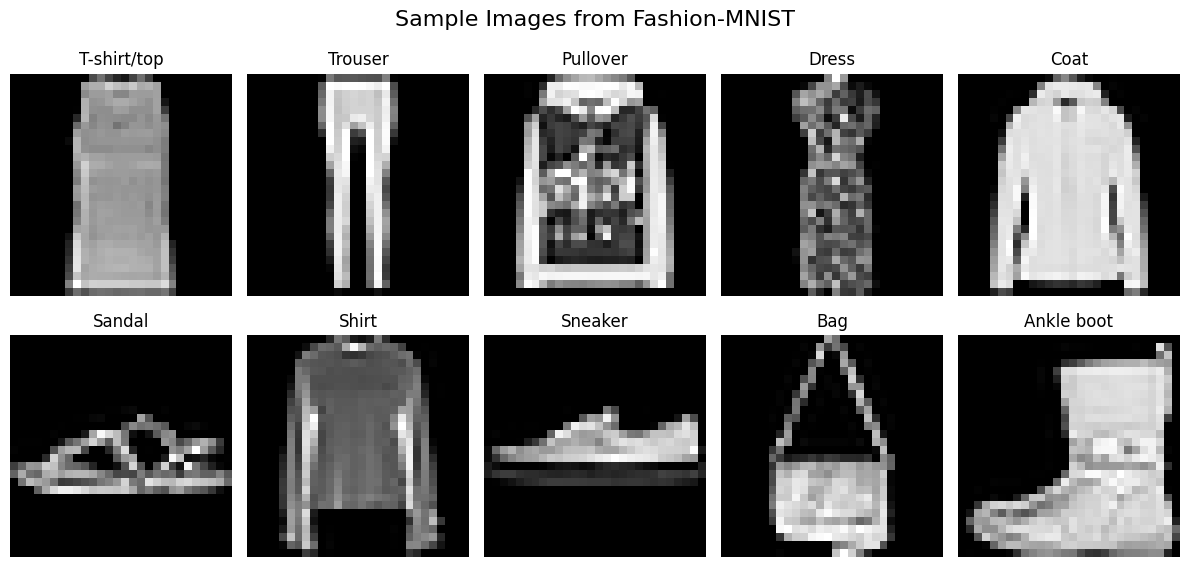

Sample images saved as 'fashion_mnist_samples.png'


In [1]:
# For demonstration, we'll use 3000 samples to ensure faster computation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import time
import warnings

warnings.filterwarnings('ignore')

n_samples = 3000
np.random.seed(42)

# Part A: Data Loading and Preparation
print("="*50)
print("Part A: Data Loading and Preparation")
print("="*50)

# Load Fashion-MNIST dataset
print("Loading Fashion-MNIST dataset...")
fashion_mnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False)
X, y = fashion_mnist.data, fashion_mnist.target.astype(int)

indices = np.random.choice(X.shape[0], n_samples, replace=False)
X = X[indices]
y = y[indices]

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {np.bincount(y)}")

# Class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Normalize pixel values
print("\nNormalizing pixel values...")
X_normalized = X / 255.0

# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(12,6))
axes = axes.ravel()
for i in range(10):
    # Find first sample of each class
    idx = np.where(y == i)[0][0]
    axes[i].imshow(X[idx].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'{class_names[i]}')
    axes[i].axis('off')

plt.suptitle('Sample Images from Fashion-MNIST', fontsize=16)
plt.tight_layout()
plt.savefig('fashion_mnist_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample images saved as 'fashion_mnist_samples.png'")


Part B: PCA Implementation
Applying PCA to reduce to 2 dimensions...
PCA computation time: 0.44 seconds


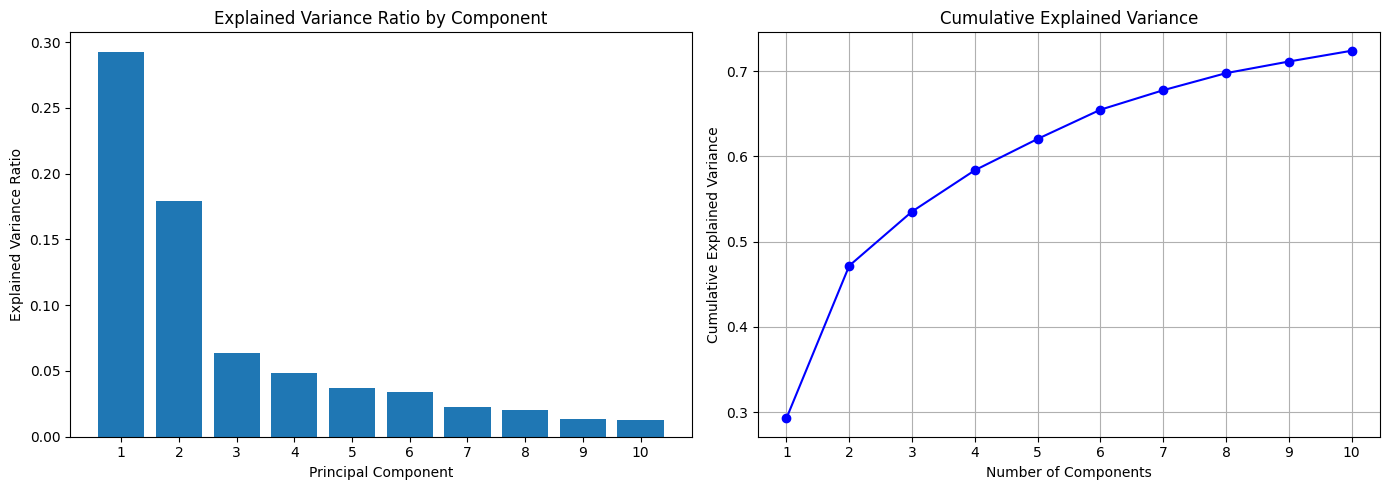

PCA variance plots saved as 'pca_variance.png'


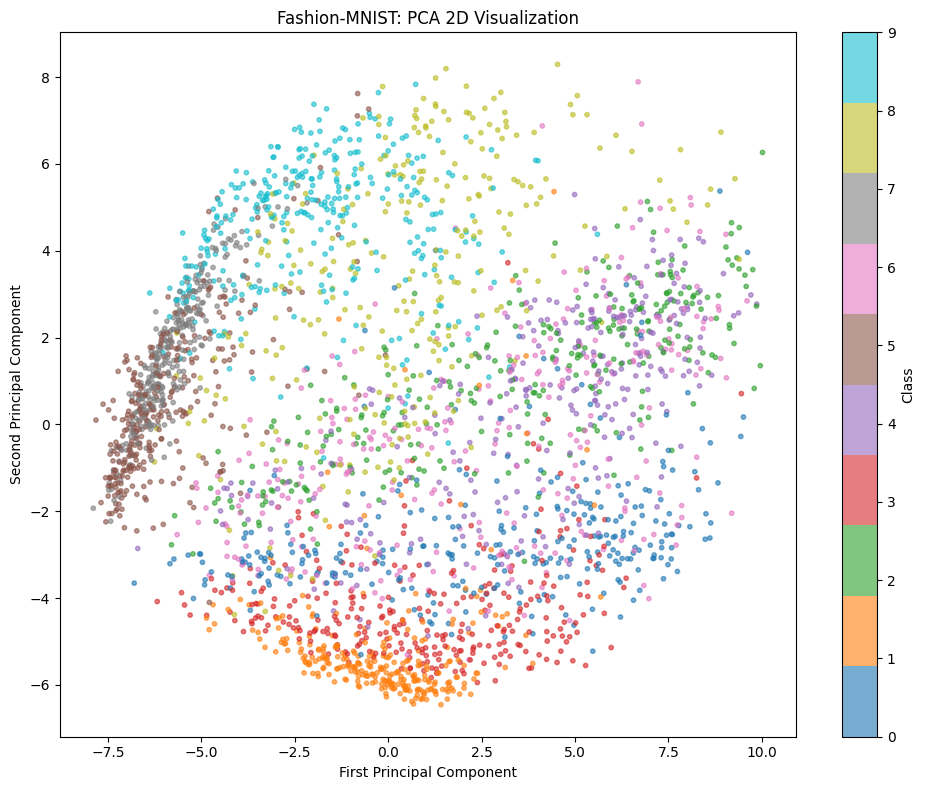

PCA visualization saved as 'pca_visualization.png'


In [2]:
# Part B: PCA Implementation
print("\n" + "=" * 50)
print("Part B: PCA Implementation")
print("=" * 50)

# Apply PCA
print("Applying PCA to reduce to 2 dimensions...")
start_time = time.time()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_normalized)
pca_time = time.time() - start_time
print(f"PCA computation time: {pca_time:.2f} seconds")

# Plot explained variance ratio
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Plot explained variance ratio for first 10 components
pca_full = PCA(n_components=10)
pca_full.fit(X_normalized)
axes[0].bar(range(1, 11), pca_full.explained_variance_ratio_[:10])
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Explained Variance Ratio by Component')
axes[0].set_xticks(range(1, 11))

# Cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, 11), cumulative_variance[:10], 'bo-')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(range(1, 11))
axes[1].grid(True)
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print("PCA variance plots saved as 'pca_variance.png'")

# Visualize data in 2D PCA space
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=10, alpha=0.6)
ax.set_xlabel('First Principal Component')
ax.set_ylabel('Second Principal Component')
ax.set_title('Fashion-MNIST: PCA 2D Visualization')
plt.colorbar(scatter, ax=ax, label='Class')
plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("PCA visualization saved as 'pca_visualization.png'")


Part C: t-SNE Implementation
Applying t-SNE with perplexity=30...
t-SNE (perp=30) computation time: 38.06 seconds
Applying t-SNE with perplexity=50...
t-SNE (perp=50) computation time: 34.15 seconds
Applying t-SNE with perplexity=100...
t-SNE (perp=100) computation time: 45.65 seconds


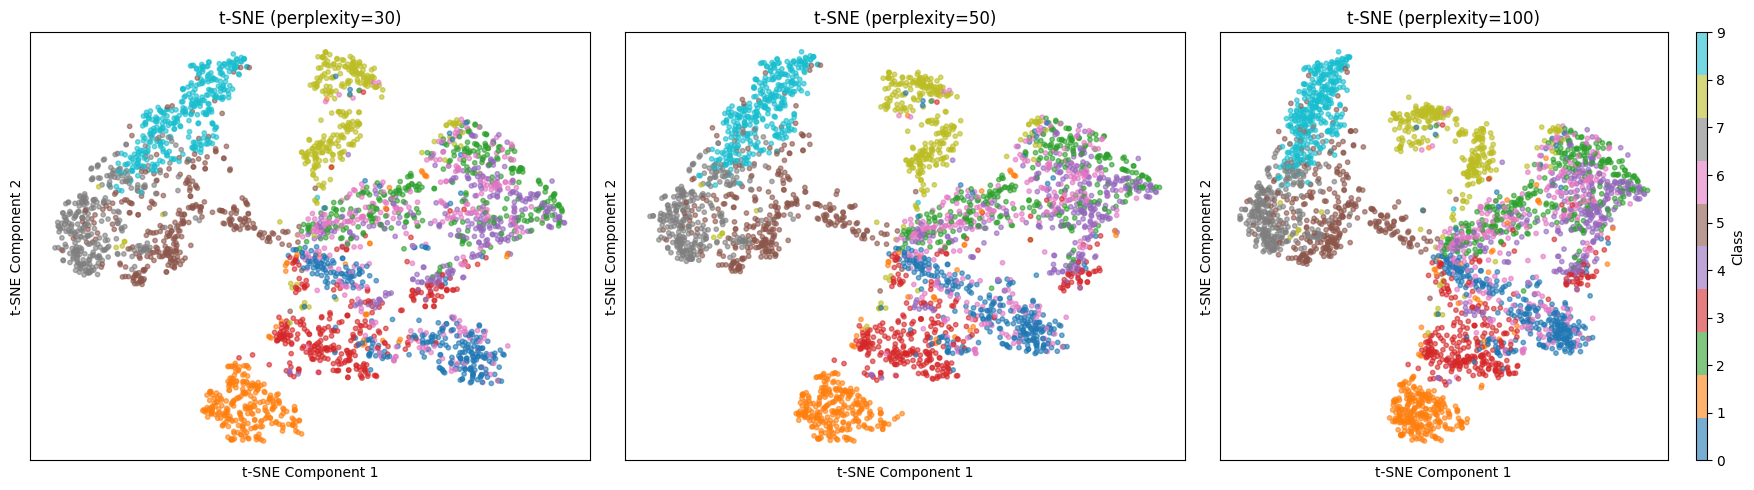

t-SNE comparison saved as 'tsne_comparison.png'


In [3]:
# Part C: t-SNE Implementation
print("\n" + "=" * 50)
print("Part C: t-SNE Implementation")
print("=" * 50)

perplexities = [30, 50, 100]
tsne_results = {}
tsne_times = {}

fig, axes = plt.subplots(1, len(perplexities), figsize=(18,5))

for i, perplexity in enumerate(perplexities):
    print(f"Applying t-SNE with perplexity={perplexity}...")
    start_time = time.time()
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, max_iter=1000)
    X_tsne = tsne.fit_transform(X_normalized)
    tsne_time = time.time() - start_time
    tsne_results[perplexity] = X_tsne
    tsne_times[perplexity] = tsne_time
    print(f"t-SNE (perp={perplexity}) computation time: {tsne_time:.2f} seconds")

    # Visualize
    scatter = axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=10, alpha=0.6)
    axes[i].set_xlabel('t-SNE Component 1')
    axes[i].set_ylabel('t-SNE Component 2')
    axes[i].set_title(f't-SNE (perplexity={perplexity})')
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.colorbar(scatter, ax=axes[-1], label='Class', aspect=40)
plt.tight_layout()
plt.savefig('tsne_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("t-SNE comparison saved as 'tsne_comparison.png'")


Part D: Comparison and Analysis

--- Computation Time Comparison ---
PCA time: 0.44 seconds
t-SNE (perplexity=30) time: 38.06 seconds
t-SNE (perplexity=50) time: 34.15 seconds
t-SNE (perplexity=100) time: 45.65 seconds


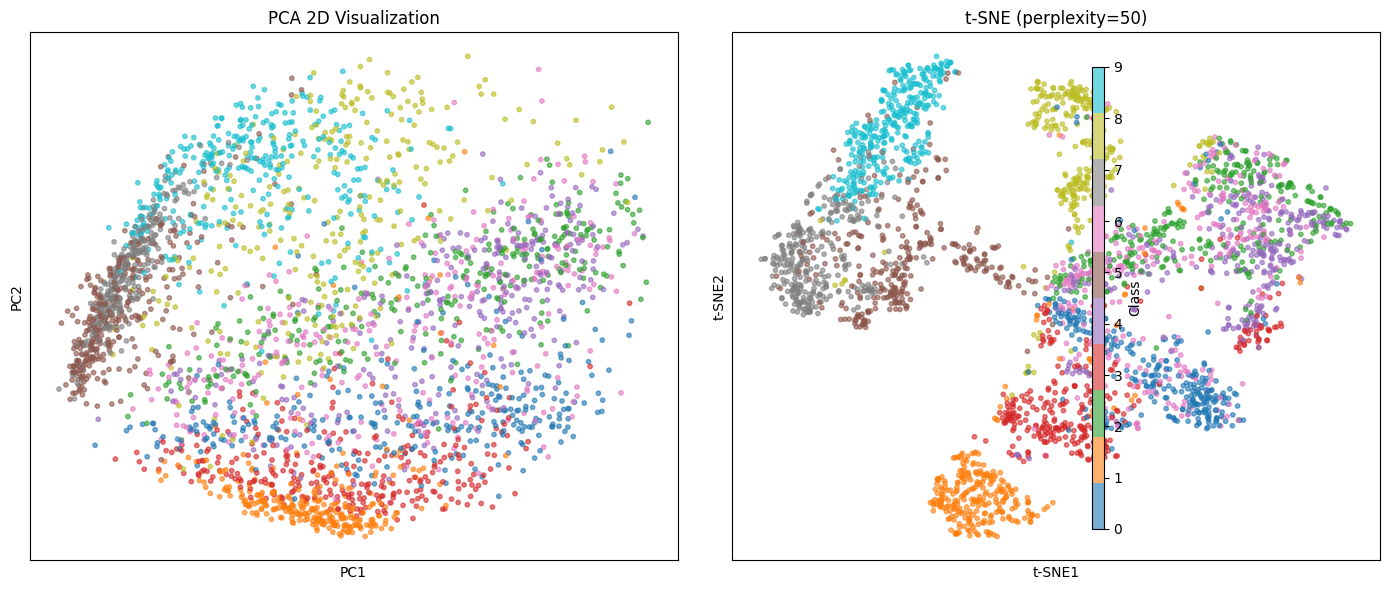

PCA vs t-SNE comparison saved as 'pca_vs_tsne.png'

--- Cluster Separation Analysis ---

Quantitative Comparison:
PCA silhouette score: -0.036
t-SNE (perp=30) silhouette score: 0.167
t-SNE (perp=50) silhouette score: 0.177
t-SNE (perp=100) silhouette score: 0.167


In [4]:
# Part D: Comparison and Analysis
print("\n" + "=" * 50)
print("Part D: Comparison and Analysis")
print("=" * 50)

# Compare computation time
print("\n--- Computation Time Comparison ---")
print(f"PCA time: {pca_time:.2f} seconds")
for perplexity, time_taken in tsne_times.items():
    print(f"t-SNE (perplexity={perplexity}) time: {time_taken:.2f} seconds")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA plot
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=10, alpha=0.6)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA 2D Visualization')
axes[0].set_xticks([])
axes[0].set_yticks([])

# t-SNE plot (best perplexity - usually 50)
best_perplexity = 50 # Typically good balance
scatter2 = axes[1].scatter(tsne_results[best_perplexity][:, 0],
                           tsne_results[best_perplexity][:, 1],
                           c=y, cmap='tab10', s=10, alpha=0.6)
axes[1].set_xlabel('t-SNE1')
axes[1].set_ylabel('t-SNE2')
axes[1].set_title(f't-SNE (perplexity={best_perplexity})')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.colorbar(scatter1, ax=axes, label='Class', aspect=40)
plt.tight_layout()
plt.savefig('pca_vs_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print("PCA vs t-SNE comparison saved as 'pca_vs_tsne.png'")

# Analysis of cluster separation
print("\n--- Cluster Separation Analysis ---")
def analyze_clusters(X_embedded, y_true, method_name):
    if len(np.unique(y_true)) > 1 and X_embedded.shape[0] > 1:
        try:
            # Use sample of data if too large for silhouette score
            if X_embedded.shape[0] > 10000:
                sample_idx = np.random.choice(X_embedded.shape[0], 10000, replace=False)
                score = silhouette_score(X_embedded[sample_idx], y_true[sample_idx])
            else:
                score = silhouette_score(X_embedded, y_true)
            print(f"{method_name} silhouette score: {score:.3f}")
        except Exception as e:
            print(f"{method_name} silhouette score calculation failed: {e}")

print("\nQuantitative Comparison:")
analyze_clusters(X_pca, y, "PCA")
for perplexity in perplexities:
    analyze_clusters(tsne_results[perplexity], y, f"t-SNE (perp={perplexity})")